<a href="https://colab.research.google.com/github/Uma-Energy/Oil-and-AI/blob/main/SlugePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This script developed by Michael & Miracle establishes a sophisticated machine learning pipeline designed to predict oil sludge formation by transitioning from raw data to interpretable regression models. The process begins with Data Loading and Initial Exploration, where oil sludge datasets are imported from Excel. During this phase, the script conducts rigorous quality checks to identify missing values or duplicates and cleans column names to ensure the programming environment is organized. Once the data is refined, the Data Preparation stage begins; here, the script isolates the "SludgeMass" target variable from its features and splits the data into training and testing sets. To ensure numerical stability, a preprocessing pipeline handles median imputation for any gaps and applies standard scaling to normalize feature ranges.The core of the analytical engine resides in the Model Definition and Cross-Validation phase. The script integrates several powerful algorithms including Random Forest, Polynomial SVR, Gradient Boosting, XGBoost, and LightGBM into individual pipelines. These are initially vetted using K-Fold Cross-Validation to establish baseline performance metrics such as Root Mean Squared Error (RMSE) and $R^2$. To further refine these models, the script generates Learning Curves, which allow the developer to diagnose whether a model is suffering from high bias (underfitting) or high variance (overfitting) as the training size increases.To achieve peak predictive power, the script utilizes Hyperparameter Tuning and Nested Cross-Validation. By using RandomizedSearchCV within a nested framework, the script avoids "data leakage" and provides a highly unbiased estimate of how the models will perform in the real world. This rigorous tuning ensures that the final models are not just memorizing the training data but are learning the underlying chemical and physical drivers of sludge formation. After tuning, a Final Model Evaluation is conducted on a completely unseen test set to confirm the accuracy of the winners.The workflow concludes with Model Diagnostics and Interpretability, moving beyond simple numbers to explain why the models make certain predictions. By generating predicted-versus-actual plots and residual analyses, the script identifies specific areas where the model might struggle. Furthermore, it employs both native feature importance and model-agnostic Permutation Importance to rank which variables such as temperature, pressure, or chemical composition most significantly impact sludge mass. The final output is a comprehensive summary table that ranks all tested models, providing a clear path forward for industrial application.

In [ ]:
# Project Setup
# Predicting Oil Sludge Formation (Seplat Energy OML 4, 38, 41, 53, 55)
# ML Framework in Python

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Tuple, List

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
# Load Dataset
# Source: Seplat Energy OML 4, 38, 41, 53, 55 Sludge Data

DATA_URL = "https://raw.githubusercontent.com/MICHAEL121233/SlugeAnalysis/refs/heads/main/SlugeDatasetSeplat.xlsx"

df = pd.read_excel(DATA_URL)

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (144, 11)


,Sample,Sa/Ar,As/Re,BS&W (%),Flowing Temperature (°F),Flowing Pressure (psi),API Gravity @ 60°F,Crude Viscosity @ 60°F (cp),WAT (°F),Wax Content (%),Sludge Mass (g sludge/g oil)
0,84S,7.640,0.176,26.16,170,1156,30.09,4.88,105.43,18.00,0.196
1,24S,2.793,0.167,18.27,224,486,27.84,1.53,104.53,20.58,0.228
2,48S,2.991,0.261,22.04,190,1248,26.24,2.36,92.24,13.75,0.167
3,33S,4.036,0.277,9.13,151,273,26.15,5.40,95.14,12.62,0.121
4,60S,4.558,0.050,11.25,195,1019,32.96,3.22,110.34,20.21,0.169


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sample                        144 non-null    object 
 1   Sa/Ar                         144 non-null    float64
 2   As/Re                         144 non-null    float64
 3   BS&W (%)                      144 non-null    float64
 4   Flowing Temperature (°F)      144 non-null    int64  
 5   Flowing Pressure (psi)        144 non-null    int64  
 6   API Gravity @ 60°F            144 non-null    float64
 7   Crude Viscosity @ 60°F (cp)   144 non-null    float64
 8   WAT (°F)                      144 non-null    float64
 9   Wax Content (%)               144 non-null    float64
 10  Sludge Mass (g sludge/g oil)  144 non-null    float64
dtypes: float64(8), int64(2), object(1)
memory usage: 12.5+ KB


None

In [ ]:
# Data Quality Checks

# Check missing values
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values per column:\n", missing)

# Check duplicates
dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)

# Quick data type check
print("\nDtypes:\n", df.dtypes)

Missing values per column:
 Sample                          0
Sa/Ar                           0
As/Re                           0
BS&W (%)                        0
Flowing Temperature (°F)        0
Flowing Pressure (psi)          0
API Gravity @ 60°F              0
Crude Viscosity @ 60°F (cp)     0
WAT (°F)                        0
Wax Content (%)                 0
Sludge Mass (g sludge/g oil)    0
dtype: int64

Duplicate rows: 0

Dtypes:
 Sample                           object
Sa/Ar                           float64
As/Re                           float64
BS&W (%)                        float64
Flowing Temperature (°F)          int64
Flowing Pressure (psi)            int64
API Gravity @ 60°F              float64
Crude Viscosity @ 60°F (cp)     float64
WAT (°F)                        float64
Wax Content (%)                 float64
Sludge Mass (g sludge/g oil)    float64
dtype: object


In [ ]:
# Clean Column Names

df = df.rename(columns={
    "BS&W (%)": "BSW_pct",
    "Flowing Temperature (°F)": "FlowingTemp_F",
    "Flowing Pressure (psi)": "FlowingPressure_psi",
    "API Gravity @ 60°F": "API_60F",
    "Crude Viscosity @ 60°F (cp)": "Viscosity_cp_60F",
    "WAT (°F)": "WAT_F",
    "Wax Content (%)": "WaxContent_pct",
    "Sludge Mass (g sludge/g oil)": "SludgeMass"
})

print("Updated columns:\n", df.columns.tolist())
display(df.head())

Updated columns:
 ['Sample', 'Sa/Ar', 'As/Re', 'BSW_pct', 'FlowingTemp_F', 'FlowingPressure_psi', 'API_60F', 'Viscosity_cp_60F', 'WAT_F', 'WaxContent_pct', 'SludgeMass']


,Sample,Sa/Ar,As/Re,BSW_pct,FlowingTemp_F,FlowingPressure_psi,API_60F,Viscosity_cp_60F,WAT_F,WaxContent_pct,SludgeMass
0,84S,7.640,0.176,26.16,170,1156,30.09,4.88,105.43,18.00,0.196
1,24S,2.793,0.167,18.27,224,486,27.84,1.53,104.53,20.58,0.228
2,48S,2.991,0.261,22.04,190,1248,26.24,2.36,92.24,13.75,0.167
3,33S,4.036,0.277,9.13,151,273,26.15,5.40,95.14,12.62,0.121
4,60S,4.558,0.050,11.25,195,1019,32.96,3.22,110.34,20.21,0.169


In [ ]:
# Define Features and Target

TARGET = "SludgeMass"
ID_COL = "Sample"

feature_cols = [c for c in df.columns if c not in [TARGET, ID_COL]]

X = df[feature_cols].copy()
y = df[TARGET].copy()

print("X shape:", X.shape, "| y shape:", y.shape)
print("Features:", feature_cols)

X shape: (144, 9) | y shape: (144,)
Features: ['Sa/Ar', 'As/Re', 'BSW_pct', 'FlowingTemp_F', 'FlowingPressure_psi', 'API_60F', 'Viscosity_cp_60F', 'WAT_F', 'WaxContent_pct']


In [ ]:
# Train/Test Split (No Leakage)

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (115, 9) Test: (29, 9)


In [ ]:
# Preprocessing Pipeline

numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

In [ ]:
# Define Models
# Models included:
# 1) Random Forest (baseline ensemble)
# 2) Polynomial SVR (classic nonlinear regression)
# 3) Gradient Boosting Regressor (sklearn boosting baseline)
# 4) XGBoost Regressor (strong boosting model)
# 5) LightGBM Regressor (efficient boosting model)


models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        random_state=RANDOM_STATE
    ),
    "PolySVR": SVR(kernel="poly", degree=2),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_estimators=500,
        learning_rate=0.05
    ),
    "LightGBM": LGBMRegressor(
        random_state=RANDOM_STATE,
        n_estimators=500,
        learning_rate=0.05,
        verbose=-1
    )
}

# Build pipelines to ensure:
# - no data leakage (scaling is fitted only on train folds)
# - consistent preprocessing across models
pipelines = {
    name: Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    for name, model in models.items()
}

pipelines

{'RandomForest': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Sa/Ar', 'As/Re', 'BSW_pct',
                                                    'FlowingTemp_F',
                                                    'FlowingPressure_psi',
                                                    'API_60F',
                                                    'Viscosity_cp_60F', 'WAT_F',
                                                    'WaxContent_pct'])])),
                 ('model',
                  RandomForestRegressor(n_estimators=500, random_state=42)

In [ ]:
#  Robust Model Evaluation Using K-Fold Cross Validation
# Why CV?
# - With small datasets (n=144), a single split can give misleading results.
# - K-fold CV provides mean performance and variability across folds.

def rmse(y_true, y_pred) -> float:
    """Compute Root Mean Squared Error."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_summary = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe,
        X_train, y_train,
        cv=kf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    cv_summary.append({
        "Model": name,
        "RMSE_mean": -scores["test_rmse"].mean(),
        "RMSE_std": scores["test_rmse"].std(),
        "MAE_mean": -scores["test_mae"].mean(),
        "R2_mean": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std()
    })

cv_results_df = pd.DataFrame(cv_summary).sort_values("RMSE_mean")
display(cv_results_df)

,Model,RMSE_mean,RMSE_std,MAE_mean,R2_mean,R2_std
2,GradientBoosting,0.017467,0.003320,0.013294,0.848640,0.047575
0,RandomForest,0.020749,0.002380,0.016327,0.789058,0.043091
4,LightGBM,0.020769,0.004206,0.016442,0.777001,0.102606
3,XGBoost,0.021735,0.003653,0.017497,0.770958,0.048647
1,PolySVR,0.049150,0.003768,0.039308,-0.175755,0.155119


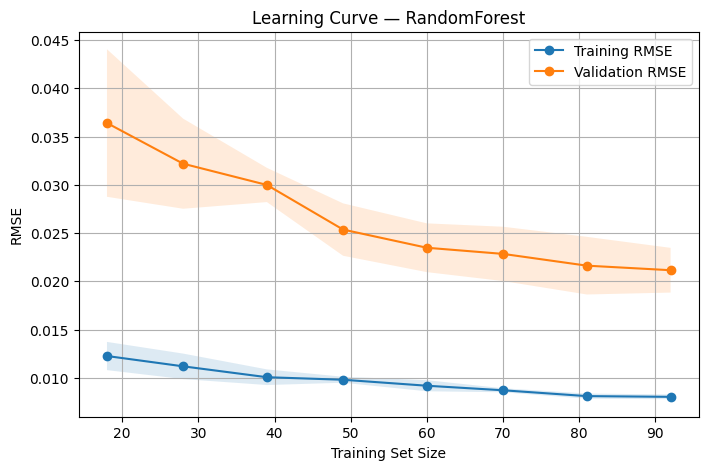

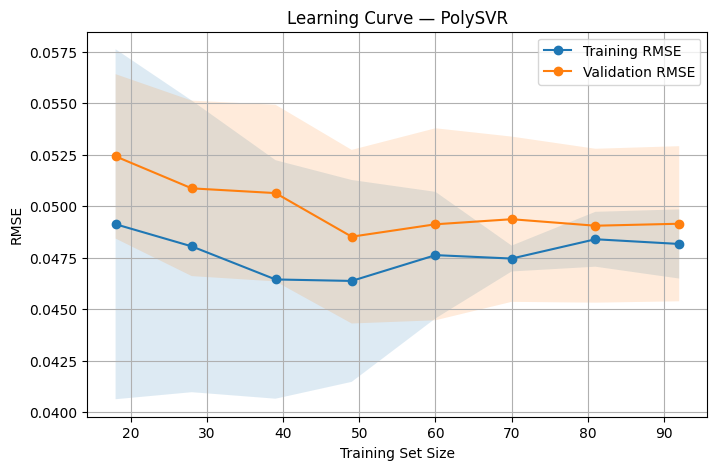

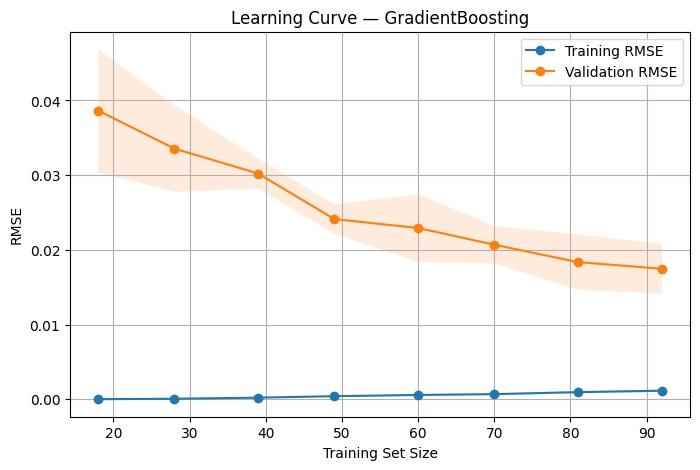

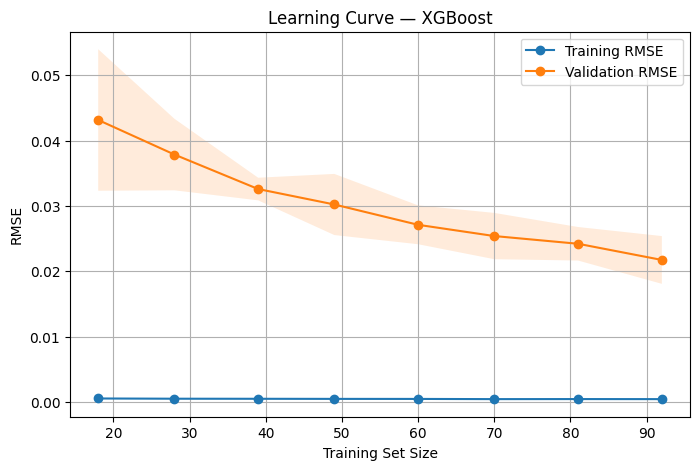

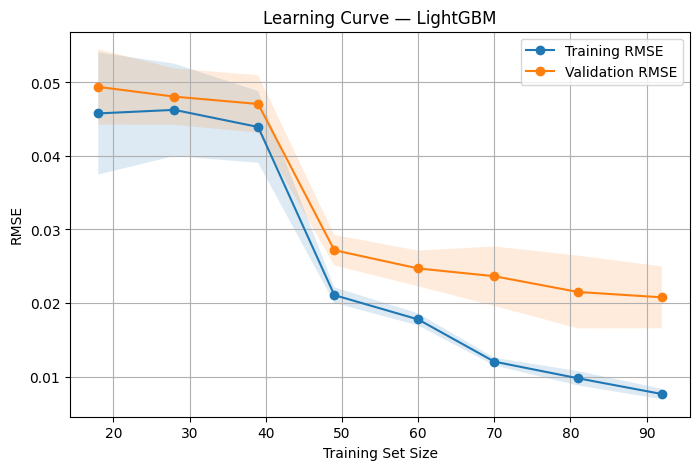

In [ ]:
# Learning Curves (Overfitting / Underfitting Diagnostic)
# Purpose:
# - Shows how performance changes as training set size increases
# - Helps diagnose overfitting (big gap: train >> CV)
# - Helps diagnose underfitting (both train & CV poor)

from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title: str, cv, train_sizes=np.linspace(0.2, 1.0, 8)):
    """
    Plot learning curve for a given pipeline (preprocess + model).

    Parameters
    ----------
    estimator : sklearn Pipeline
        Pipeline containing preprocessing and model.
    X, y : pd.DataFrame, pd.Series
        Features and target.
    title : str
        Plot title.
    cv : sklearn CV splitter
        Cross-validation strategy.
    train_sizes : array-like
        Fractions or absolute sizes of training set to use.
    """
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X, y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        train_sizes=train_sizes,
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # Convert from negative RMSE to positive RMSE
    train_rmse = -train_scores
    val_rmse = -val_scores

    train_mean = train_rmse.mean(axis=1)
    train_std = train_rmse.std(axis=1)

    val_mean = val_rmse.mean(axis=1)
    val_std = val_rmse.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training RMSE")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

    plt.plot(train_sizes, val_mean, marker="o", label="Validation RMSE")
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Plot learning curves for ALL models
for name, pipe in pipelines.items():
    plot_learning_curve(
        estimator=pipe,
        X=X_train,
        y=y_train,
        title=f"Learning Curve — {name}",
        cv=kf
    )

In [ ]:
# Nested Cross-Validation (Unbiased Estimate)
# Purpose:
# - Gives a more trustworthy performance estimate for tuned models.
# - Outer CV: evaluates generalization
# - Inner CV: performs hyperparameter tuning (RandomizedSearchCV)
# Why needed it:
# - Standard CV + tuning can be optimistic if the same data influences tuning decisions.
# - Nested CV reduces this bias and is best practice for small datasets.
# Output:
# - Mean ± Std RMSE and R² across outer folds (for each model)

from sklearn.base import clone

outer_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

nested_summary = []

for model_name, base_pipe in pipelines.items():
    print(f" Nested CV running for: {model_name}")

    outer_rmses = []
    outer_r2s = []

    # Outer loop (evaluation)
    for train_idx, val_idx in outer_cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Inner loop (tuning) — clone to ensure independence each fold
        pipe = clone(base_pipe)

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_grids[model_name],
            n_iter=40,
            scoring="neg_root_mean_squared_error",
            cv=inner_cv,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        search.fit(X_tr, y_tr)

        best_est = search.best_estimator_
        preds = best_est.predict(X_val)

        outer_rmses.append(rmse(y_val, preds))
        outer_r2s.append(r2_score(y_val, preds))

    nested_summary.append({
        "Model": model_name,
        "Nested_RMSE_mean": float(np.mean(outer_rmses)),
        "Nested_RMSE_std": float(np.std(outer_rmses)),
        "Nested_R2_mean": float(np.mean(outer_r2s)),
        "Nested_R2_std": float(np.std(outer_r2s))
    })

nested_cv_df = pd.DataFrame(nested_summary).sort_values("Nested_RMSE_mean")
display(nested_cv_df)

🧪 Nested CV running for: RandomForest
🧪 Nested CV running for: PolySVR
🧪 Nested CV running for: GradientBoosting
🧪 Nested CV running for: XGBoost
🧪 Nested CV running for: LightGBM


,Model,Nested_RMSE_mean,Nested_RMSE_std,Nested_R2_mean,Nested_R2_std
1,PolySVR,0.008837,0.001007,0.962249,0.004816
2,GradientBoosting,0.013260,0.002496,0.913107,0.026438
3,XGBoost,0.014714,0.002069,0.891947,0.032700
4,LightGBM,0.021221,0.005187,0.761386,0.130501
0,RandomForest,0.021754,0.002706,0.766958,0.055196


In [ ]:
# Hyperparameter Tuning (RandomizedSearchCV)
# Purpose:
# - Improve model generalization by searching good hyperparameters
# - Avoid manual tuning that is not reproducible
# Important:
# - Tuning is done ONLY on the training set
# - CV is used inside the tuning loop (nested validation)

param_grids = {
    "RandomForest": {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__max_depth": [None, 3, 5, 8, 12],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", 0.6, 0.8]
    },
    "PolySVR": {
        "model__C": np.logspace(-1, 3, 20),
        "model__epsilon": np.linspace(0.001, 0.1, 20),
        "model__degree": [2, 3],
        "model__gamma": ["scale", "auto"],
        "model__coef0": [0.0, 0.5, 1.0, 2.0]
    },
    "GradientBoosting": {
        "model__n_estimators": [200, 500, 800, 1200],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5, 6],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_alpha": [0, 0.001, 0.01, 0.1],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0]
    },
    "LightGBM": {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__num_leaves": [7, 15, 31, 63],
        "model__max_depth": [-1, 3, 5, 7],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_alpha": [0, 0.001, 0.01, 0.1],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0]
    }
}

best_models = {}
tuning_results = []

for name, pipe in pipelines.items():
    print(f"Tuning: {name}")

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grids[name],
        n_iter=40,  # can be increase to 80–150 for deeper search
        scoring="neg_root_mean_squared_error",
        cv=kf,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best_RMSE_CV": -search.best_score_,
        "Best_Params": search.best_params_
    })

tuning_df = pd.DataFrame(tuning_results).sort_values("Best_RMSE_CV")
display(tuning_df)

Tuning: RandomForest
Tuning: PolySVR
Tuning: GradientBoosting
Tuning: XGBoost
Tuning: LightGBM


,Model,Best_RMSE_CV,Best_Params
1,PolySVR,0.008837,"{'model__gamma': 'scale', 'model__epsilon': 0...."
2,GradientBoosting,0.012855,"{'model__subsample': 0.8, 'model__n_estimators..."
3,XGBoost,0.014302,"{'model__subsample': 1.0, 'model__reg_lambda':..."
4,LightGBM,0.020106,"{'model__subsample': 0.6, 'model__reg_lambda':..."
0,RandomForest,0.021684,"{'model__n_estimators': 300, 'model__min_sampl..."


In [ ]:
# Final Evaluation on Unseen Test Set

# This is the ONLY evaluation that should appear in the final conclusion table
# because it represents generalization to new/unseen samples.

final_rows = []

for name, best_pipe in best_models.items():
    best_pipe.fit(X_train, y_train)
    preds = best_pipe.predict(X_test)

    final_rows.append({
        "Model": name,
        "Test_RMSE": rmse(y_test, preds),
        "Test_MAE": mean_absolute_error(y_test, preds),
        "Test_R2": r2_score(y_test, preds)
    })

final_results_df = pd.DataFrame(final_rows).sort_values("Test_RMSE")
display(final_results_df)

,Model,Test_RMSE,Test_MAE,Test_R2
1,PolySVR,0.008759,0.006892,0.976384
2,GradientBoosting,0.013855,0.010991,0.940920
3,XGBoost,0.017117,0.013659,0.909819
4,LightGBM,0.021993,0.017400,0.851131
0,RandomForest,0.022626,0.018430,0.842438


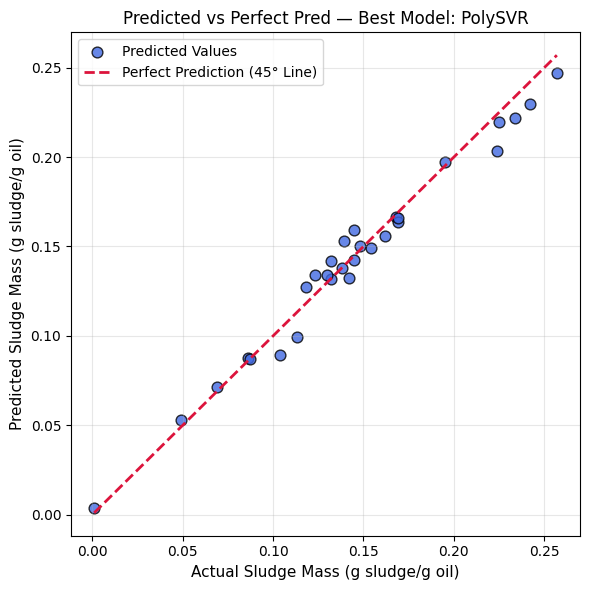

In [ ]:
# Predicted vs perfect prediction Plot

best_name = final_results_df.iloc[0]["Model"]
best_model = best_models[best_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))

# Scatter plot (predictions)
plt.scatter(
    y_test,
    y_pred,
    color="royalblue",
    edgecolor="black",
    alpha=0.8,
    s=60,
    label="Predicted Values"
)

# 45-degree reference line (perfect prediction)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction (45° Line)"
)

plt.xlabel("Actual Sludge Mass (g sludge/g oil)", fontsize=11)
plt.ylabel("Predicted Sludge Mass (g sludge/g oil)", fontsize=11)
plt.title(f"Predicted vs Perfect Pred — Best Model: {best_name}", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

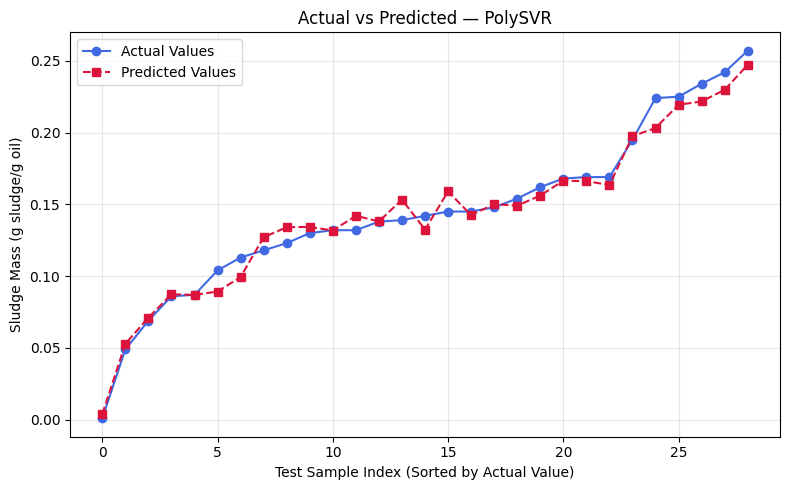

In [ ]:
# Actual vs Predicted Line Plot

best_name = final_results_df.iloc[0]["Model"]
best_model = best_models[best_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# Sort by actual values for clean visualization
sorted_idx = np.argsort(y_test.values)
y_test_sorted = y_test.values[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    y_test_sorted,
    color="royalblue",
    marker="o",
    linestyle="-",
    label="Actual Values"
)

plt.plot(
    y_pred_sorted,
    color="crimson",
    marker="s",
    linestyle="--",
    label="Predicted Values"
)

plt.xlabel("Test Sample Index (Sorted by Actual Value)")
plt.ylabel("Sludge Mass (g sludge/g oil)")
plt.title(f"Actual vs Predicted — {best_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

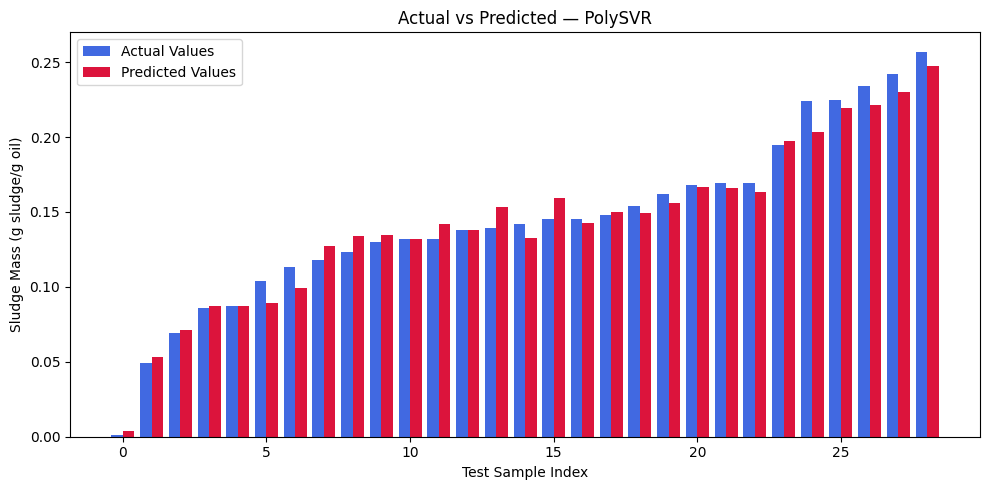

In [ ]:
plt.figure(figsize=(10, 5))

x_axis = np.arange(len(y_test_sorted))

plt.bar(x_axis - 0.2, y_test_sorted, width=0.4, label="Actual Values", color="royalblue")
plt.bar(x_axis + 0.2, y_pred_sorted, width=0.4, label="Predicted Values", color="crimson")

plt.xlabel("Test Sample Index")
plt.ylabel("Sludge Mass (g sludge/g oil)")
plt.title(f"Actual vs Predicted — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

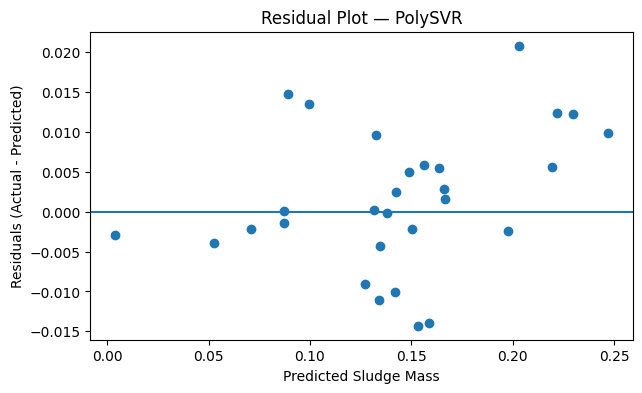

In [ ]:
# Residual Diagnostics
# Residuals help detect:
# - bias (systematic under/over prediction)
# - heteroscedasticity (variance changes with prediction level)
# - outliers

residuals = y_test - y_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Sludge Mass")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title(f"Residual Plot — {best_name}")
plt.show()

,Feature,Importance_mean,Importance_std
8,WaxContent_pct,1.662376,0.318042
5,API_60F,0.193935,0.033530
2,BSW_pct,0.186792,0.044333
7,WAT_F,0.149689,0.031611
1,As/Re,0.004399,0.002646
3,FlowingTemp_F,0.003848,0.003049
0,Sa/Ar,0.002593,0.002282
4,FlowingPressure_psi,0.000550,0.000605
6,Viscosity_cp_60F,-0.000838,0.001862


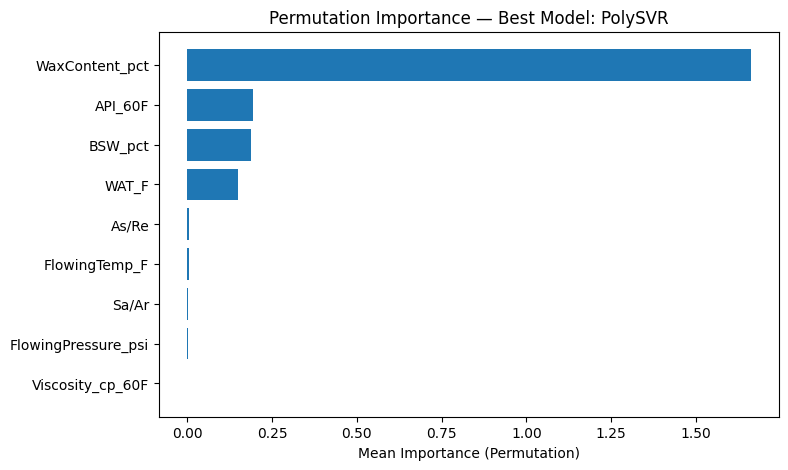

In [ ]:
# Permutation Importance (Model-Agnostic)
# It measures the drop in performance
# when each feature is randomly shuffled.

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "Feature": numeric_features,
    "Importance_mean": perm.importances_mean,
    "Importance_std": perm.importances_std
}).sort_values("Importance_mean", ascending=False)

display(perm_imp)

plt.figure(figsize=(8, 5))
plt.barh(perm_imp["Feature"], perm_imp["Importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Mean Importance (Permutation)")
plt.title(f"Permutation Importance — Best Model: {best_name}")
plt.show()

In [ ]:
# Native Feature Importance (Tree Models)
# Note: For SVR, there is no native feature importance.

tree_models = ["RandomForest", "GradientBoosting", "XGBoost", "LightGBM"]

fi_tables = {}

for model_name in tree_models:
    m = best_models[model_name]
    m.fit(X_train, y_train)
    estimator = m.named_steps["model"]


    importances = estimator.feature_importances_

    fi = pd.DataFrame({
        "Feature": numeric_features,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    fi_tables[model_name] = fi

    print(f"\n=== Feature Importance: {model_name} ===")
    display(fi.head(10))


=== Feature Importance: RandomForest ===


,Feature,Importance
8,WaxContent_pct,0.444286
5,API_60F,0.198067
0,Sa/Ar,0.112653
2,BSW_pct,0.093745
1,As/Re,0.073334
7,WAT_F,0.031840
4,FlowingPressure_psi,0.020411
3,FlowingTemp_F,0.012878
6,Viscosity_cp_60F,0.012786



=== Feature Importance: GradientBoosting ===


,Feature,Importance
8,WaxContent_pct,0.498113
5,API_60F,0.217622
2,BSW_pct,0.130327
0,Sa/Ar,0.065438
1,As/Re,0.042570
7,WAT_F,0.036345
4,FlowingPressure_psi,0.006574
3,FlowingTemp_F,0.002126
6,Viscosity_cp_60F,0.000884



=== Feature Importance: XGBoost ===


,Feature,Importance
8,WaxContent_pct,0.275815
0,Sa/Ar,0.221549
5,API_60F,0.195825
2,BSW_pct,0.163693
3,FlowingTemp_F,0.106735
7,WAT_F,0.025458
4,FlowingPressure_psi,0.004487
6,Viscosity_cp_60F,0.003707
1,As/Re,0.002730



=== Feature Importance: LightGBM ===


,Feature,Importance
8,WaxContent_pct,305
5,API_60F,271
6,Viscosity_cp_60F,220
0,Sa/Ar,207
2,BSW_pct,200
7,WAT_F,182
4,FlowingPressure_psi,145
3,FlowingTemp_F,109
1,As/Re,68


In [ ]:
# Final Summary Table (For Report)

summary_table = final_results_df.copy()
summary_table["Dataset"] = "Seplat Energy OML 4, 38, 41, 53, 55 Sludge Data"
summary_table = summary_table[["Dataset", "Model", "Test_RMSE", "Test_MAE", "Test_R2"]]

display(summary_table)

,Dataset,Model,Test_RMSE,Test_MAE,Test_R2
1,"Seplat Energy OML 4, 38, 41, 53, 55 Sludge Data",PolySVR,0.008759,0.006892,0.976384
2,"Seplat Energy OML 4, 38, 41, 53, 55 Sludge Data",GradientBoosting,0.013855,0.010991,0.940920
3,"Seplat Energy OML 4, 38, 41, 53, 55 Sludge Data",XGBoost,0.017117,0.013659,0.909819
4,"Seplat Energy OML 4, 38, 41, 53, 55 Sludge Data",LightGBM,0.021993,0.017400,0.851131
0,"Seplat Energy OML 4, 38, 41, 53, 55 Sludge Data",RandomForest,0.022626,0.018430,0.842438
